In [4]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Shrusti R\Downloads\olist_project\notebook
['.ipynb_checkpoints', 'DAY_1_EXPLORATION.ipynb', 'DAY_2_Data_understanding.ipynb', 'DAY_3_Data Cleaning & Preparation.ipynb', 'Untitled.ipynb']


In [26]:
import os

for root, dirs, files in os.walk(os.path.expanduser("~")):
    if "olist_orders_dataset.csv" in files:
        print(os.path.join(root, "olist_orders_dataset.csv"))

C:\Users\Shrusti R\Downloads\olist_project\data\olist_orders_dataset.csv\olist_orders_dataset.csv


In [27]:
orders = pd.read_csv(r"C:\Users\Shrusti R\Downloads\olist_project\data\olist_orders_dataset.csv\olist_orders_dataset.csv")

In [24]:
print(orders.shape)
orders.head()

(99441, 11)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,delivery_performance,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,On Time,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,On Time,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,On Time,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,On Time,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,On Time,2018-02


In [28]:
#Make sure the dates are proper dates
orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

In [29]:
#Calculate delivery delay
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.days

In [30]:
#Create On-Time / Late categories
orders['delivery_performance'] = orders['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0 else 'On Time'
)

In [31]:
# Step 1: Select only delivered orders
delivered_orders = orders[
    orders['order_status'] == 'delivered'
].copy()

# Step 2: Calculate delivery delay
delivered_orders['delivery_delay_days'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_estimated_delivery_date']
).dt.days

# Step 3: Classify delivery performance
delivered_orders['delivery_performance'] = delivered_orders[
    'delivery_delay_days'
].apply(
    lambda x: 'Late' if x > 0 else 'On Time'
)

# Step 4: Count each category
delivery_counts = delivered_orders[
    'delivery_performance'
].value_counts()

print(delivery_counts)

delivery_performance
On Time    89944
Late        6534
Name: count, dtype: int64


In [43]:
import pandas as pd
order_items = pd.read_csv(r"C:\Users\Shrusti R\Downloads\olist_project\data\olist_order_items_dataset.csv\olist_order_items_dataset.csv")

In [44]:
print(orders.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_delay_days', 'delivery_performance', 'month'],
      dtype='object')


In [45]:
# Make sure order purchase date is datetime
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

# Add month
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Merge orders with order items
sales_data = orders[
    ['order_id', 'month']
].merge(
    order_items[['order_id', 'price']],
    on='order_id',
    how='inner'
)

# Monthly sales analysis
monthly_sales = sales_data.groupby('month').agg(
    GMV=('price', 'sum'),
    Orders=('order_id', 'nunique')
).reset_index()

# Average order value
monthly_sales['Average_Order_Value'] = (
    monthly_sales['GMV'] / monthly_sales['Orders']
)

print(monthly_sales.head())

     month        GMV  Orders  Average_Order_Value
0  2016-09     267.36       3            89.120000
1  2016-10   49507.66     308           160.739156
2  2016-12      10.90       1            10.900000
3  2017-01  120312.87     789           152.487795
4  2017-02  247303.02    1733           142.702262


In [46]:
print(order_items.head())
print(order_items.shape)

                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00          17.87  
3  2018-08-15 10:10:18   12.99          12.7

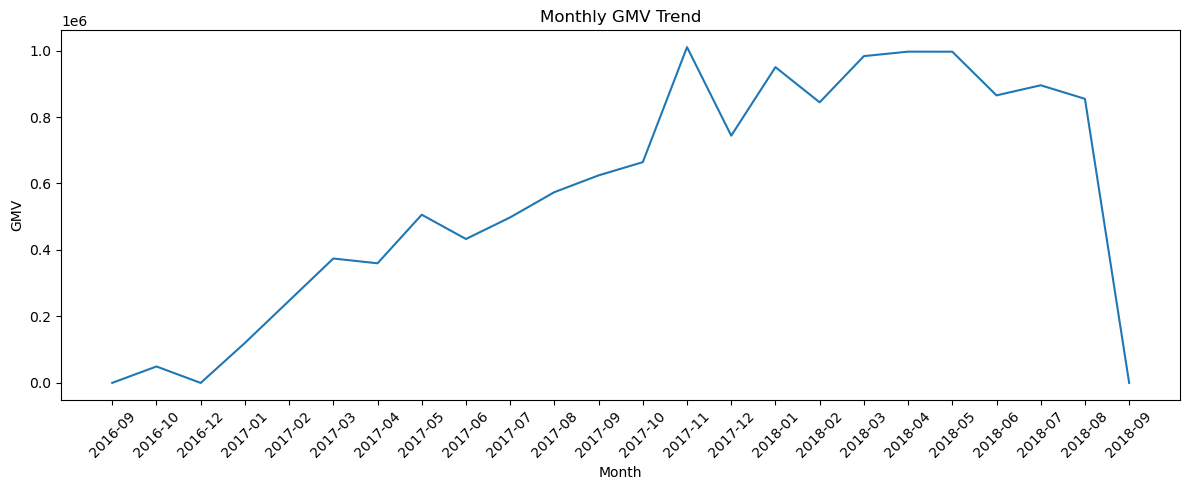

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['month'].astype(str),
    monthly_sales['GMV']
)

plt.title('Monthly GMV Trend')
plt.xlabel('Month')
plt.ylabel('GMV')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [49]:
best_month = monthly_sales.loc[
    monthly_sales['GMV'].idxmax()
]

worst_month = monthly_sales.loc[
    monthly_sales['GMV'].idxmin()
]

print("Best Sales Month:")
print(best_month)

print("\nWorst Sales Month:")
print(worst_month)

Best Sales Month:
month                     2017-11
GMV                    1010271.37
Orders                       7451
Average_Order_Value    135.588695
Name: 13, dtype: object

Worst Sales Month:
month                  2016-12
GMV                       10.9
Orders                       1
Average_Order_Value       10.9
Name: 2, dtype: object


In [50]:
average_order_value = monthly_sales['GMV'].sum() / monthly_sales['Orders'].sum()

print(f"Average Order Value: R$ {average_order_value:.2f}")

Average Order Value: R$ 137.75


In [51]:
highest_aov_month = monthly_sales.loc[
    monthly_sales['Average_Order_Value'].idxmax()
]

print("Highest Average Order Value:")
print(highest_aov_month)

Highest Average Order Value:
month                     2016-10
GMV                      49507.66
Orders                        308
Average_Order_Value    160.739156
Name: 1, dtype: object


In [52]:
lowest_aov_month = monthly_sales.loc[
    monthly_sales['Average_Order_Value'].idxmin()
]

print("\nLowest Average Order Value:")
print(lowest_aov_month)


Lowest Average Order Value:
month                  2016-12
GMV                       10.9
Orders                       1
Average_Order_Value       10.9
Name: 2, dtype: object


In [54]:
import pandas as pd
products = pd.read_csv(r"C:\Users\Shrusti R\Downloads\olist_project\data\olist_products_dataset.csv\olist_products_dataset.csv")

In [55]:
print(products.head())
print(products.shape)

                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0       

In [56]:
#Add the product category to each sold item so we can compare category-level sales.
category_sales = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

print(category_sales.head())

                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value product_category_name  
0  2017-09-19 09:45:35   58.90          13.29            cool_stuff  
1  2017-05-03 11:05:13  239.90          19.93              pet_shop  
2  2018-01-18 14:48:30  19

In [57]:
category_gmv = (
    category_sales
    .groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
)

print(category_gmv.head(10))

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64


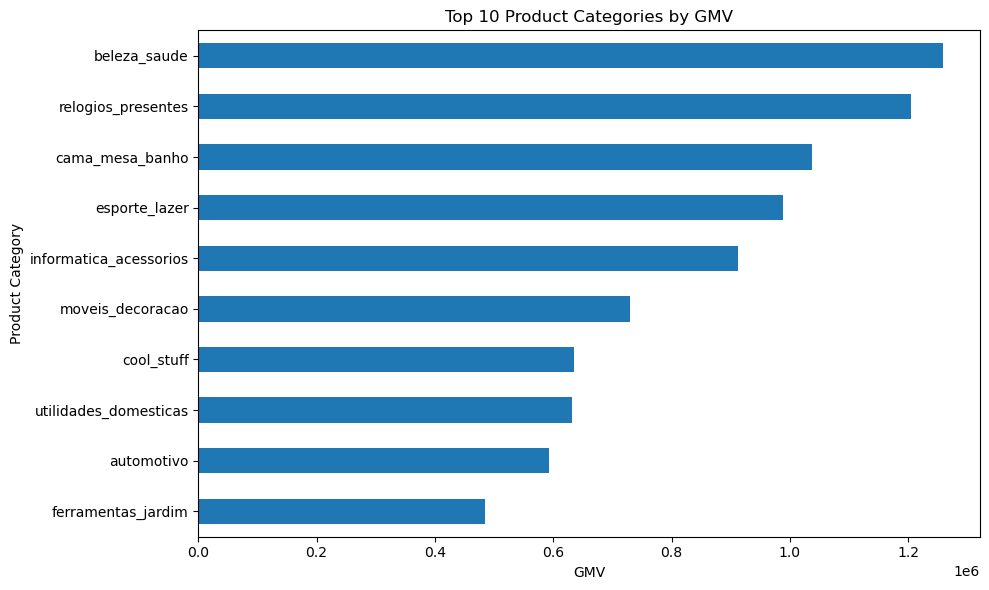

In [58]:
import matplotlib.pyplot as plt

top_categories = category_gmv.head(10)

plt.figure(figsize=(10, 6))

top_categories.sort_values().plot(kind='barh')

plt.title('Top 10 Product Categories by GMV')
plt.xlabel('GMV')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

In [59]:
category_orders = (
    category_sales
    .groupby('product_category_name')['order_id']
    .nunique()
    .sort_values(ascending=False)
)

print(category_orders.head(10))

product_category_name
cama_mesa_banho           9417
beleza_saude              8836
esporte_lazer             7720
informatica_acessorios    6689
moveis_decoracao          6449
utilidades_domesticas     5884
relogios_presentes        5624
telefonia                 4199
automotivo                3897
brinquedos                3886
Name: order_id, dtype: int64


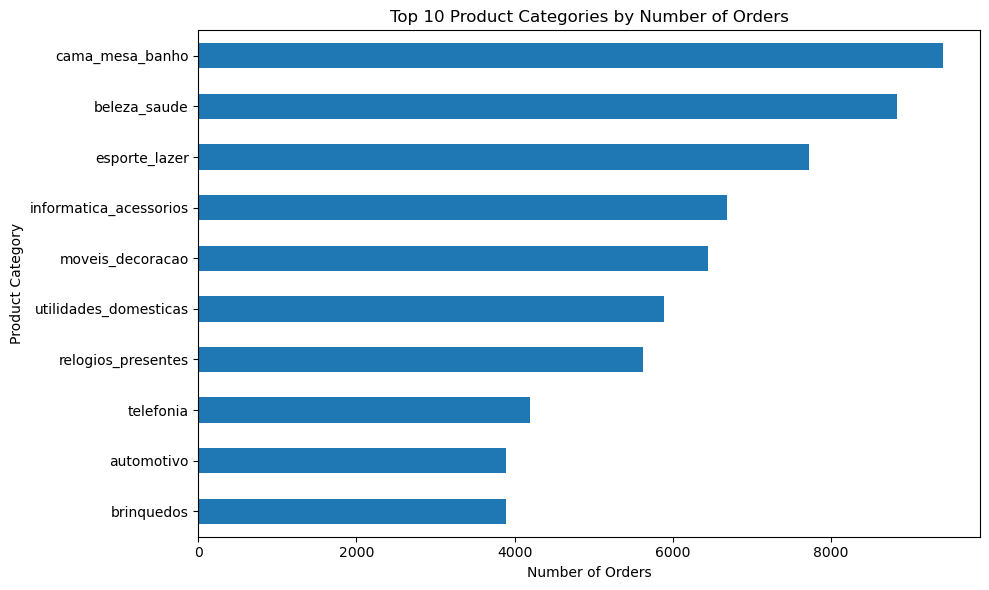

In [60]:
plt.figure(figsize=(10, 6))

category_orders.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Product Categories by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

In [89]:
import pandas as pd
customers = pd.read_csv(r"C:\Users\Shrusti R\Downloads\olist_project\data\olist_customers_dataset.csv\olist_customers_dataset.csv")

In [90]:
print(customers.head())
print(customers.shape)

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
(99441, 5)


In [91]:
customer_orders = (
    orders
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
    .groupby('customer_unique_id')['order_id']
    .nunique()
)

print(customer_orders.describe())

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: order_id, dtype: float64


In [92]:
customer_type = customer_orders.apply(
    lambda x: 'Repeat Customer' if x > 1 else 'One-Time Customer'
)

customer_type_counts = customer_type.value_counts()

print(customer_type_counts)

order_id
One-Time Customer    93099
Repeat Customer       2997
Name: count, dtype: int64


In [93]:
repeat_customer_rate = (
    customer_type.eq('Repeat Customer').mean() * 100
)

print(f"Repeat Customer Rate: {repeat_customer_rate:.2f}%")

Repeat Customer Rate: 3.12%
